<a href="https://www.kaggle.com/code/nagapranayimmadi/proteus-arc?scriptVersionId=322494840" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# Input data files are available in the read-only "../input/" directory
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import tkinter as tk
from tkinter import filedialog
import math
import random
from itertools import combinations
import statistics
import networkx as nx 
import matplotlib.pyplot as plt 
import scipy.io
from scipy.io import loadmat
from scipy.io.matlab import MatReadError
import mne

/kaggle/input/datasets/nagapranayimmadi/semi-filtered-eeg-data-openneuro/derivatives/sub-060/eeg/sub-060_task-eyesclosed_eeg.set
/kaggle/input/datasets/nagapranayimmadi/semi-filtered-eeg-data-openneuro/derivatives/sub-003/eeg/sub-003_task-eyesclosed_eeg.set
/kaggle/input/datasets/nagapranayimmadi/semi-filtered-eeg-data-openneuro/derivatives/sub-012/eeg/sub-012_task-eyesclosed_eeg.set
/kaggle/input/datasets/nagapranayimmadi/semi-filtered-eeg-data-openneuro/derivatives/sub-057/eeg/sub-057_task-eyesclosed_eeg.set
/kaggle/input/datasets/nagapranayimmadi/semi-filtered-eeg-data-openneuro/derivatives/sub-015/eeg/sub-015_task-eyesclosed_eeg.set
/kaggle/input/datasets/nagapranayimmadi/semi-filtered-eeg-data-openneuro/derivatives/sub-048/eeg/sub-048_task-eyesclosed_eeg.set
/kaggle/input/datasets/nagapranayimmadi/semi-filtered-eeg-data-openneuro/derivatives/sub-034/eeg/sub-034_task-eyesclosed_eeg.set
/kaggle/input/datasets/nagapranayimmadi/semi-filtered-eeg-data-openneuro/derivatives/sub-010/eeg/

# SEGMENT 1: FULL EDGE-BY-EDGE ALGORITHM

# RANDOMIZATION SEGMENT TO BE IMPLEMENTED LATER

# Step 1. Data Processing / Deciding which Data to use

In terms of actually processing the EEG data, removing all of the noise, etc

In [4]:
data_input = (input('what data are you using? (enter "n" for new data, use "p" for premade data to test ')).lower()

if data_input == "n": 
    # note this will only work in the API version which will be used in the interface
    # also, update this segment when you are making the inferace
    print("Now you will have to enter your data")
    def openFile():
        filepath = filedialog.askopenfilepath()
        file = open(filepath, 'r')
        reading_file = pd.read_csv('filepath')
        
    window = tk()
    button = Button(text="Open", command=openFile)
    button.pack()
    window.mainloop()

# to use the data that is already in the algorithm for testing purposes
if data_input == "p":
    print("Using the dataset for this algorithm that is in the code to test")
    # we turn these csv's into having each row and column for each node have a different list which can be iterated over
    healthy1 = pd.read_csv('/kaggle/input/datasets/nigarmahmoudshafiq/nigar-eeg-alzheimers-dataset-v1/Final dataset for the published paper/1-Healthy/CN13.csv') 
    # factoring time out of the algorithm (TEMPORARILY MAY CHANGE)
    # ________________________________________________________________________
    # if str(healthy1.iloc[:, 1]) == "time":
    #    healthy1 = healthy1.drop('time', axis=1)
    # ________________________________________________________________________
    # converts the dataframe into a dictionary
    healthy1_dict = {
    col: healthy1[col].tolist()
    for col in healthy1.columns
}    
# ________________________________________________________________________
# COMMENTED OUT(WILL BE UNCOMMENTED WHEN NEEDED FOR TESTING PURPOSES)
#print(healthy1_dict) 
# ________________________________________________________________________
    moderate1 = pd.read_csv('/kaggle/input/datasets/nigarmahmoudshafiq/nigar-eeg-alzheimers-dataset-v1/Final dataset for the published paper/3-Moderate/Mod8.csv')
    mild1 = pd.read_csv('/kaggle/input/datasets/nigarmahmoudshafiq/nigar-eeg-alzheimers-dataset-v1/Final dataset for the published paper/2-Mild/Mild1.csv')
    severe1 = pd.read_csv('/kaggle/input/datasets/nigarmahmoudshafiq/nigar-eeg-alzheimers-dataset-v1/Final dataset for the published paper/4-Sever/Sv2.csv')

# to make the user know they inputted an invalid input
elif data_input != "p" and data_input !="n": 
    print("You did not enter a valid input, retry")

what data are you using? (enter "n" for new data, use "p" for premade data to test  p


Using the dataset for this algorithm that is in the code to test


In [39]:
# OpenNeuro Dataset
openneuro_dataset = []
for path in range(1, 89):
    file_path = f"/kaggle/input/datasets/nagapranayimmadi/openneuro-filtered-data/sub-{path:03d}_task-eyesclosed_eeg.set"
    openneuro_dataset.append(file_path)
# ________________________________________________________________________
# COMMENTED OUT(WILL BE UNCOMMENTED WHEN NEEDED FOR TESTING PURPOSES)
#print(openneuro_dataset)
# ________________________________________________________________________
# Load .set file into csv usable format
csv_openneuro_dataset = []
for csv_convert in openneuro_dataset:
    try:
        x = loadmat(csv_convert, appendmat=False)
        data = x["data"]
        # Extract channel/node names
        channels = [c[0][0] for c in x["chanlocs"][0]]
        # Convert to CSV format 
        df = pd.DataFrame(data.T, columns=channels)
        # Save CSV
        df.to_csv("eeg_nodes.csv", index=False)
        csv_openneuro_dataset.append(df)
    except MatReadError as e:
        pass 
print(csv_openneuro_dataset[0].head())

# convert the data that is present in the nodes into actual node voltage data


         Fp1        Fp2         F3         F4         C3         C4  \
0 -13.547649 -12.982911 -12.864223 -15.478166 -14.479111 -13.763200   
1 -11.324695 -11.243111 -11.418202 -12.831456 -12.530659 -12.309750   
2  -9.635249 -10.635274 -10.457741 -10.389472 -11.389046 -11.383709   
3  -8.576221 -11.317549 -10.057194  -8.279247 -11.209035 -11.001395   
4  -8.057809 -13.146663 -10.146156  -6.540730 -11.932675 -11.040858   

          P3         P4         O1         O2        F7         F8         T3  \
0 -12.896243 -12.010491 -10.874237 -16.251282 -9.170815 -11.719826  -9.477215   
1 -12.009327 -10.326769  -9.490935 -14.584904 -7.110390 -10.089147  -8.760719   
2 -12.108236  -9.543666  -9.292492 -13.933581 -6.229019  -9.643548  -9.435384   
3 -13.207009  -9.709988 -10.311228 -14.381600 -6.587485 -10.475169 -11.520432   
4 -15.070707 -10.628815 -12.288774 -15.741675 -7.928393 -12.354836 -14.667753   

          T4         T5        T6         Fz         Cz         Pz  
0  -6.309359 -10.

# Step 2. Graph Creation

![](http://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSEp2A_l2XGVWDGnfBpe_4bZ2OmKFTH6zJo0g&s) uses this formula for the Pearson Coefficient

/tmp/ipykernel_57/1602538447.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
Fp1,0.000000,0.867669,0.760537,0.734322,0.346765,0.439261,0.269912,0.288732,0.165531,0.129301,0.574286,0.619825,0.068603,0.025958,0.132489,0.113352,0.786707,0.535060,0.304944
Fp2,0.867669,0.000000,0.580971,0.672788,0.284575,0.429919,0.247211,0.295019,0.182868,0.145635,0.369731,0.709333,0.003702,0.041528,0.121198,0.146775,0.675767,0.465846,0.289172
F3,0.760537,0.580971,0.000000,0.766268,0.614815,0.542109,0.451452,0.382264,0.300621,0.248636,0.747253,0.472724,0.281337,0.064168,0.322710,0.207148,0.910462,0.760260,0.472007
F4,0.734322,0.672788,0.766268,0.000000,0.505237,0.664194,0.413733,0.448450,0.325403,0.308048,0.465411,0.679493,0.162011,0.196543,0.297880,0.290006,0.902220,0.736669,0.472997
C3,0.346765,0.284575,0.614815,0.505237,0.000000,0.596054,0.845867,0.525187,0.607963,0.481118,0.518537,0.309631,0.444474,0.164763,0.708339,0.387580,0.557231,0.727256,0.698313
C4,0.439261,0.429919,0.542109,0.664194,0.596054,0.000000,0.647833,0.820570,0.612744,0.622208,0.325495,0.539511,0.244533,0.430423,0.526396,0.634410,0.628734,0.764383,0.763651
P3,0.269912,0.247211,0.451452,0.413733,0.845867,0.647833,0.000000,0.757196,0.869090,0.723032,0.398179,0.326225,0.432947,0.302421,0.898301,0.608655,0.422009,0.691802,0.899721
P4,0.288732,0.295019,0.382264,0.448450,0.525187,0.820570,0.757196,0.000000,0.819960,0.866186,0.249480,0.412509,0.280607,0.474001,0.665641,0.850420,0.426712,0.667499,0.898929
O1,0.165531,0.182868,0.300621,0.325403,0.607963,0.612744,0.869090,0.819960,0.000000,0.916687,0.256531,0.334399,0.383793,0.420536,0.885569,0.783190,0.296248,0.542463,0.842958
O2,0.129301,0.145635,0.248636,0.308048,0.481118,0.622208,0.723032,0.866186,0.916687,0.000000,0.170975,0.319773,0.308911,0.466620,0.731075,0.870857,0.267115,0.489727,0.776496


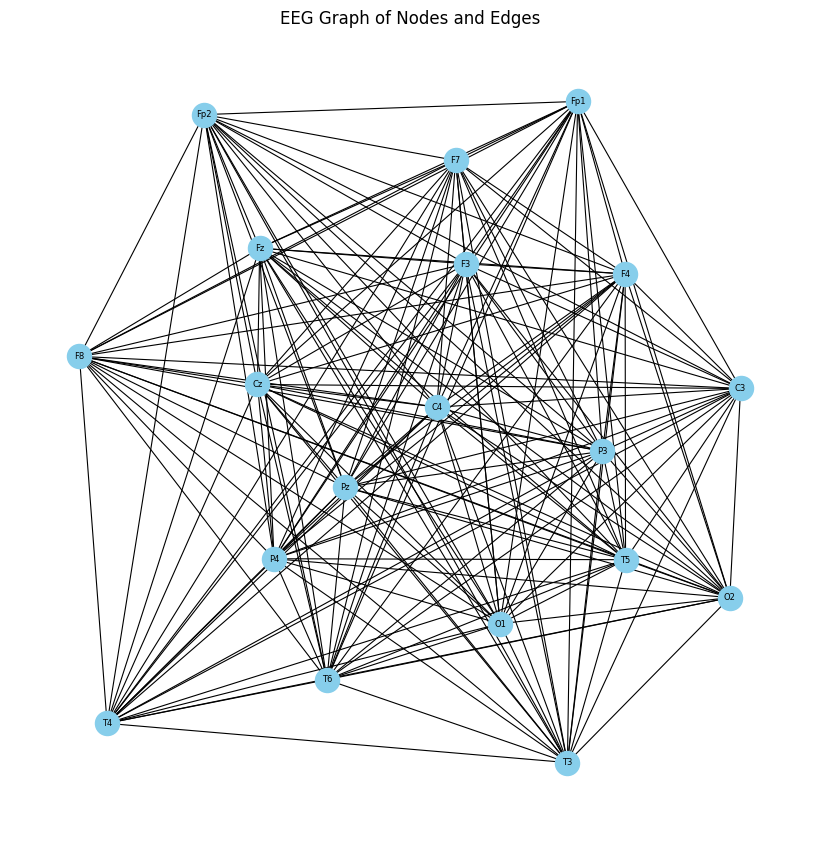

In [120]:
## Getting all possible node connections
key = []
connectivity = []
connectivity_dict = {}
list_of_nodes = healthy1_dict.keys() 
list_of_nodes = list(list_of_nodes) # helps make the dataframe for the adjacency matrix
# ________________________________________________________________________
# COMMENTED OUT(WILL BE UNCOMMENTED WHEN NEEDED FOR TESTING PURPOSES)
# print(list_of_nodes)
# ________________________________________________________________________
# Creating the dataframe
df = pd.DataFrame(columns=list_of_nodes, index=list_of_nodes)
for node1, node2 in combinations(healthy1_dict, 2):
    # Pearson Connectivity Formula
      # key for the key-value pair of connectivity values
    key_of_connectivity = (node1, node2)
    key.append(key_of_connectivity)
    # x, y for the node values, z for calculating the Pearson Correlation 
    x = (healthy1_dict.get(node1))
    y = (healthy1_dict.get(node2))
    z = statistics.correlation(x, y)
    connectivity.append(z)
    # creating the connectivity dictionary
    connectivity_dict.update({key_of_connectivity : z})
    df.loc[node1, node2] = z 
    df.loc[node2, node1] = z
df = df.fillna(0)
# Step 1. Create an Adjacency Matrix
display(df)
# ________________________________________________________________________
# COMMENTED OUT(WILL BE UNCOMMENTED WHEN NEEDED FOR TESTING PURPOSES)
#print(connectivity_dict) 
# ________________________________________________________________________

# Step 2. Corrosponding the Node Values
node_values = {}
for values in healthy1_dict.keys():
    node_mean = statistics.mean(healthy1_dict.get(values))
    node_value = values
    node_values.update({ node_value : node_mean })
# ________________________________________________________________________
# COMMENTED OUT(WILL BE UNCOMMENTED WHEN NEEDED FOR TESTING PURPOSES)
#print(node_values) 
# ________________________________________________________________________

# Step 3. Create the nx Graph
plt.figure(figsize=(8, 8))
# G is initialized here.
G = nx.from_pandas_adjacency(df)
nx.set_node_attributes(G, node_values, "mean_voltage")
pos = nx.spring_layout(G)
nx.draw(
    G,
    pos,
    with_labels = True,
    node_color ='skyblue',
    edge_color ='black',
    width = 0.8,
    font_size = 6
)

plt.title("EEG Graph of Nodes and Edges")
plt.show()

In [ ]:
# DYNAMIC GRAPH - FOR LATER CODE
# Multiple edge values for the same node connections need to be analyzed over time to make the data dynamic instead of static
# for time, what needs to be analyzed:
# 1. Sampling Rate in Hz - Cycles Per Second - Here it would be 250Hz of Voltage
# 2. Recording Duration - Number of Columns / Sampling Rate 
# 3. Number of Columns - Here it would be 1024 
sampling_rate = int(input("enter the sample rate(in Hz): "))
columns_number = len(healthy1_dict.get("Fp1"))
recording_duration = columns_number/sampling_rate
print(recording_duration, "seconds is the amount of time the test was done for!")
# EDIT THIS LATER

# SEGMENT 2: THE GCN
May add a transformer in the layer if the requirements of the core model are met

In [1]:
# Imports
!pip install -q torch 
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.10.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 14.2 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.4 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
random_seed = 43 # Will change later to being multiple seeds with are averaged
torch.manual_seed(1234567)
seed_everything(random_seed)
plt.style.use('dark_background')
accuracy_list = []

# Data Present 
# 1. Node and Edge Graph -> With Node & Edge Values
# so basically the input can be all of the voltages of the nodes  
# and the output is all of the new and transformed node features based on what is being done
 # These new representations will all be analyzed by an MLP which will give them an importance weight
 # Then, at the end, a simple algorithm will compile the importance weight for all the 4 different edge factors, and determine whether the person has alzheimer's 

In [ ]:
# Step 1. Setting up the Input (Dataset(s))

In [27]:
# Step 2. Defining No. Nodes, Edges, Classes
classes = {
    "healthy" : (0, 0.25),
    "mild" : (0.25, 0.50),
    "moderate" : (0.50, 0.75),
    "severe" : (0.75, 1)
}


In [ ]:
# Step 3. Defining the functions for layers and the GCN 

class GCN:
    # 
    def __init__():

    #this is for the relu activation function between hidden layers
    def relu(): 

    # for normal propogation 
    def forward(): 

    # for backpropogation 
    def backward(): 

model = GCN(hidden_channels = 16)
# ________________________________________________________________________
# COMMENTED OUT(WILL BE UNCOMMENTED WHEN NEEDED FOR TESTING PURPOSES)
#print(model) 
# ________________________________________________________________________


In [28]:
# Step 4. Training

In [ ]:
# Step 5. Validation

In [ ]:
# Step 6. Testing 

# SEGMENT 3: INFERENCE(ALZHEIMER'S PROBABILITY FOR JUST ONE PERSON) 
80% Weightage

# SEGMENT 4 - AI-BASED ALZHEIMER'S ANALYSIS BASED ON QUESTIONAIRE
20% WEIGHTAGE

In [ ]:
# Imports

In [ ]:
# Code

# SEGMENT 5 - FINAL COMPILER (DETERMINES WHETHER THE INDIVIDUAL HAS ALZHEIMER'S